# 03 — Models

Predict per-activity Strava `Relative Effort` from the features built in `02_features.ipynb`. Time-respecting split: last 15% held out, `TimeSeriesSplit(n_splits=5)` for CV.

Models compared:
1. **Ridge** baseline (linear) on all numeric features.
2. **Natural cubic splines** (`SplineTransformer`) on the top continuous features → Ridge.
3. **GAM** (`pygam.LinearGAM`) with smooth and factor terms — interpretable nonlinearity.

Outputs: `data/processed/{train,test}.parquet`, fitted models as joblib pickles, `metrics.json`, GAM partial-dependence plots.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

PROJECT_ROOT = Path.cwd()
assert PROJECT_ROOT.name == "Project"
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = DATA_DIR / "processed"

mt = pd.read_parquet(OUT_DIR / "model_table.parquet").sort_values("activity_dt").reset_index(drop=True)
print("model_table:", mt.shape)
mt.head()

model_table: (482, 57)


,activity_id,activity_dt,distance_km,moving_time_s,elapsed_time_s,elev_gain_m,avg_hr,max_hr_summary,avg_cadence_summary,relative_effort,...,dist_14d,dist_28d,dist_56d,n_runs_7d,n_runs_28d,re_7d,re_28d,atl,ctl,tsb
0,9271509294,2020-01-17 11:28:15+00:00,4.20,1455.0,1495.0,7.200000,159.0,181.0,79.0,47.0,...,38.509998,61.900002,109.919998,2.0,7.0,163.0,606.0,23.087013,17.583252,-4.160214
1,9271506822,2020-01-21 11:29:45+00:00,4.76,1301.0,1301.0,9.000000,185.0,202.0,84.0,88.0,...,4.200000,4.200000,4.200000,1.0,1.0,47.0,47.0,10.066388,11.460746,1.394357
2,9271509373,2020-02-15 15:00:10+00:00,21.27,6738.0,6763.0,34.700001,183.0,208.0,82.0,454.0,...,0.000000,4.760000,8.960000,0.0,1.0,0.0,88.0,1.110306,3.822626,2.712320
3,9271506584,2020-02-26 15:26:48+00:00,10.66,3960.0,4050.0,20.100000,185.0,196.0,80.0,241.0,...,21.270000,21.270000,30.230000,0.0,1.0,0.0,454.0,16.568708,15.548015,-1.020693
4,9271508227,2020-02-28 14:06:43+00:00,7.69,2466.0,2467.0,13.400000,178.0,202.0,79.0,137.0,...,31.930000,31.930000,40.889999,1.0,2.0,241.0,695.0,34.449871,22.298656,-12.151216


## 3.1 Time-respecting split

Sort by date, hold out the last 15% (these include the marathon taper / race-week training). Within train, use `TimeSeriesSplit(n_splits=5)` for hyperparameter selection.

In [2]:
TARGET = "relative_effort"
# Drop:
#   - target / id / datetime
#   - 'sex' (constant)
#   - 'year' (pure index; never seen in test era → leaks no signal, only OneHotEncoder warnings)
#   - 'days_to_race' (test rows have negative values absent in train → bad extrapolation)
DROP = [TARGET, "activity_id", "activity_dt", "sex", "year", "days_to_race"]

feature_cols = [c for c in mt.columns if c not in DROP and pd.api.types.is_numeric_dtype(mt[c])]
print(f"Total candidate numeric features: {len(feature_cols)}")

split_idx = int(len(mt) * 0.85)
train_df = mt.iloc[:split_idx].reset_index(drop=True)
test_df = mt.iloc[split_idx:].reset_index(drop=True)
print(f"Train: {len(train_df)} ({train_df['activity_dt'].min().date()} → {train_df['activity_dt'].max().date()})")
print(f"Test:  {len(test_df)}  ({test_df['activity_dt'].min().date()} → {test_df['activity_dt'].max().date()})")

train_df.to_parquet(OUT_DIR / "train.parquet", index=False)
test_df.to_parquet(OUT_DIR / "test.parquet", index=False)

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]
tscv = TimeSeriesSplit(n_splits=5)

# Quick distribution-shift summary — used in §3.7 to interpret negative test R²
print("\nTarget distribution (Relative Effort):")
print(f"  train: mean={y_train.mean():.1f}  std={y_train.std():.1f}  max={y_train.max():.0f}")
print(f"  test:  mean={y_test.mean():.1f}  std={y_test.std():.1f}  max={y_test.max():.0f}")


Total candidate numeric features: 51
Train: 409 (2020-01-17 → 2025-12-12)
Test:  73  (2025-12-13 → 2026-03-21)

Target distribution (Relative Effort):
  train: mean=86.2  std=83.2  max=551
  test:  mean=41.5  std=31.2  max=166


## 3.2 Pick smooth-term features

Rank candidate continuous features by mutual information with the target on the training set, then keep the top 6 for the spline / GAM smooths. `dow` and `month` enter as categorical / factor terms in the GAM.

In [3]:
CATEGORICAL = [c for c in ["dow", "month", "year", "is_long_run"] if c in feature_cols]
CONTINUOUS = [c for c in feature_cols if c not in CATEGORICAL]
print("Continuous candidates:", len(CONTINUOUS))

mi = mutual_info_regression(X_train[CONTINUOUS], y_train, random_state=0)
mi_rank = pd.Series(mi, index=CONTINUOUS).sort_values(ascending=False)
print(mi_rank.head(15))

SMOOTH_FEATURES = mi_rank.head(6).index.tolist()
print("\nChosen smooth features:", SMOOTH_FEATURES)
FACTOR_FEATURES = [c for c in ["dow", "month"] if c in feature_cols]
print("Factor features:", FACTOR_FEATURES)

Continuous candidates: 48
avg_hr            0.482799
mean_hr           0.453942
moving_time_s     0.429919
distance_km       0.418436
p50_hr            0.411036
max_hr_stream     0.403207
p90_hr            0.401120
max_hr_summary    0.397127
n_stream_rows     0.390397
elapsed_time_s    0.384776
p95_hr            0.376141
frac_z4           0.301343
frac_z2           0.285385
frac_z5           0.203866
elev_gain_m       0.200604
dtype: float64

Chosen smooth features: ['avg_hr', 'mean_hr', 'moving_time_s', 'distance_km', 'p50_hr', 'max_hr_stream']
Factor features: ['dow', 'month']


## 3.3 Ridge baseline

Standardise + linear regression with L2 penalty over all candidate features. This is the linearity benchmark.

In [4]:
def evaluate(model, name: str) -> dict:
    yp_test = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, yp_test)))
    mae = float(mean_absolute_error(y_test, yp_test))
    r2 = float(r2_score(y_test, yp_test))
    print(f"{name:>10}  test  MAE={mae:6.2f}  RMSE={rmse:6.2f}  R²={r2:.3f}")
    return {"model": name, "test_mae": mae, "test_rmse": rmse, "test_r2": r2}


pre_all = ColumnTransformer(
    [
        ("num", StandardScaler(), CONTINUOUS),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL),
    ],
    remainder="drop",
)
ridge = Pipeline([("pre", pre_all), ("est", Ridge(alpha=1.0))])

cv_rmse = -cross_val_score(ridge, X_train, y_train, cv=tscv, scoring="neg_root_mean_squared_error")
cv_mae = -cross_val_score(ridge, X_train, y_train, cv=tscv, scoring="neg_mean_absolute_error")
print(f"Ridge   CV   MAE={cv_mae.mean():.2f}±{cv_mae.std():.2f}  RMSE={cv_rmse.mean():.2f}±{cv_rmse.std():.2f}")

ridge.fit(X_train, y_train)
ridge_metrics = evaluate(ridge, "Ridge")
ridge_metrics["cv_rmse_mean"] = float(cv_rmse.mean())
ridge_metrics["cv_rmse_std"] = float(cv_rmse.std())
joblib.dump(ridge, OUT_DIR / "ridge.joblib")

Ridge   CV   MAE=36.66±8.41  RMSE=49.50±14.76
     Ridge  test  MAE= 90.77  RMSE=101.14  R²=-9.664


/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


['/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/processed/ridge.joblib']

## 3.4 Natural cubic splines

`SplineTransformer(degree=3, knots="quantile", extrapolation="linear")` on the chosen continuous features → Ridge. Other features go through scaling / one-hot. Hyperparameters (`n_knots`, `alpha`) are picked with `GridSearchCV` against `TimeSeriesSplit`.

In [5]:
other_continuous = [c for c in CONTINUOUS if c not in SMOOTH_FEATURES]

pre_spline = ColumnTransformer(
    [
        ("spline", SplineTransformer(degree=3, knots="quantile", extrapolation="linear"), SMOOTH_FEATURES),
        ("num", StandardScaler(), other_continuous),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL),
    ],
    remainder="drop",
)
spline_pipe = Pipeline([("pre", pre_spline), ("est", Ridge())])

grid = {
    "pre__spline__n_knots": [4, 6, 8, 12],
    "est__alpha": [0.1, 1.0, 10.0, 100.0],
}
spline_search = GridSearchCV(
    spline_pipe, grid, cv=tscv, scoring="neg_root_mean_squared_error", n_jobs=-1
)
spline_search.fit(X_train, y_train)
print("Best spline params:", spline_search.best_params_)
print(f"Best CV RMSE: {-spline_search.best_score_:.2f}")

spline_metrics = evaluate(spline_search.best_estimator_, "Splines")
spline_metrics["cv_rmse_mean"] = float(-spline_search.best_score_)
spline_metrics["best_params"] = {k: v for k, v in spline_search.best_params_.items()}
joblib.dump(spline_search.best_estimator_, OUT_DIR / "splines.joblib")

Best spline params: {'est__alpha': 100.0, 'pre__spline__n_knots': 4}
Best CV RMSE: 45.94
   Splines  test  MAE= 50.01  RMSE= 57.13  R²=-2.403


/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown cat

['/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/processed/splines.joblib']

## 3.5 Generalized Additive Model (GAM)

`pygam.LinearGAM` with smooth `s()` terms on the chosen continuous features and factor `f()` terms on `dow` / `month`. `gridsearch` picks the smoothness penalty `lam`. The partial-dependence panels are the headline interpretability output.

In [6]:
from functools import reduce
from operator import add

from pygam import LinearGAM, f, s

GAM_FEATURES = SMOOTH_FEATURES + FACTOR_FEATURES
X_train_gam = X_train[GAM_FEATURES].astype("float64").to_numpy()
X_test_gam = X_test[GAM_FEATURES].astype("float64").to_numpy()
y_train_arr = y_train.to_numpy().astype("float64")

terms = [s(i) for i in range(len(SMOOTH_FEATURES))] + [
    f(i) for i in range(len(SMOOTH_FEATURES), len(GAM_FEATURES))
]
gam_terms = reduce(add, terms)

gam = LinearGAM(gam_terms)
lam_grid = np.logspace(-3, 3, 11)
gam.gridsearch(X_train_gam, y_train_arr, lam=lam_grid)

yp_test = gam.predict(X_test_gam)
gam_metrics = {
    "model": "GAM",
    "test_mae": float(mean_absolute_error(y_test, yp_test)),
    "test_rmse": float(np.sqrt(mean_squared_error(y_test, yp_test))),
    "test_r2": float(r2_score(y_test, yp_test)),
    "best_lam": gam.lam,
}
print(f"{'GAM':>10}  test  MAE={gam_metrics['test_mae']:6.2f}  RMSE={gam_metrics['test_rmse']:6.2f}  R²={gam_metrics['test_r2']:.3f}")
joblib.dump({"gam": gam, "features": GAM_FEATURES}, OUT_DIR / "gam.joblib")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


       GAM  test  MAE= 35.77  RMSE= 50.36  R²=-1.644


['/Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/processed/gam.joblib']

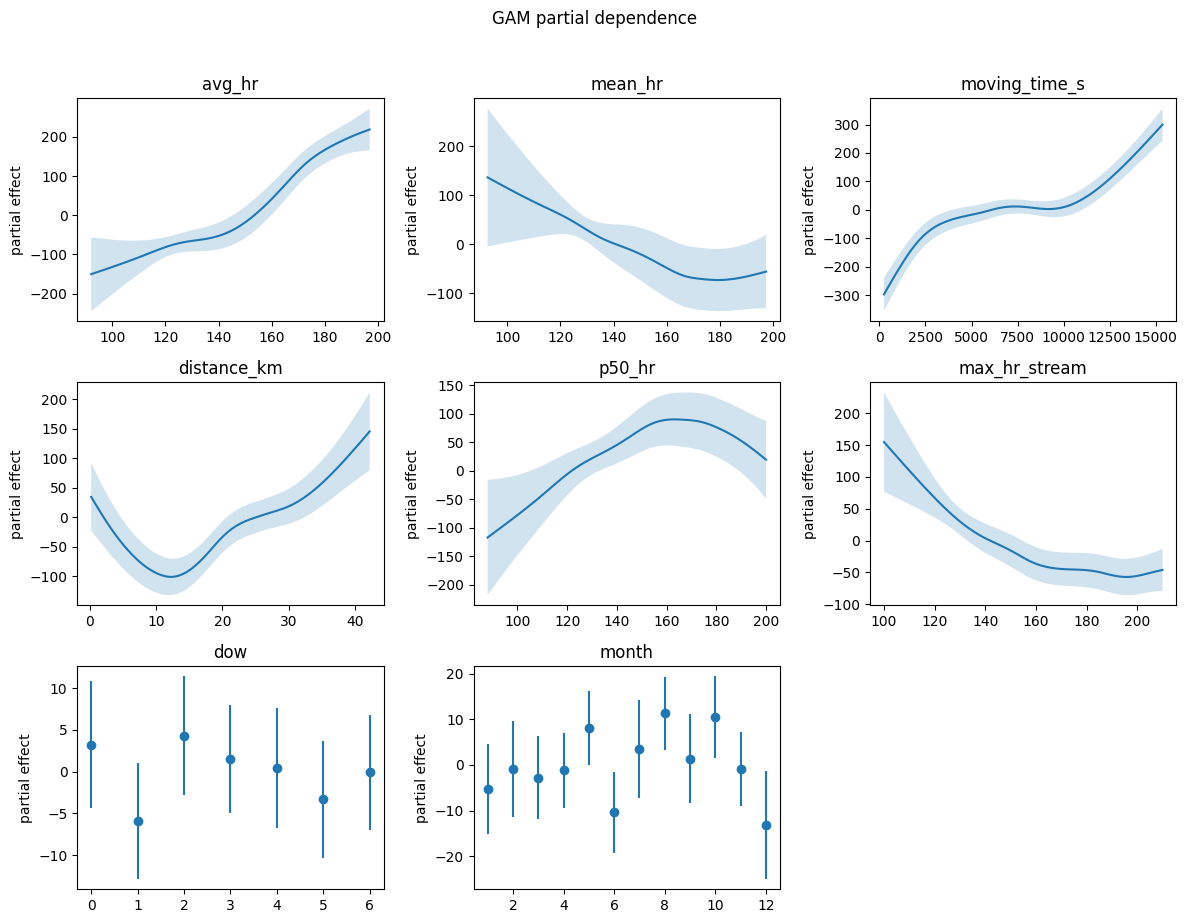

In [7]:
# Build a partial-dependence plot per term.
# pygam's generate_X_grid sets non-target columns to their mean — which produces
# illegal non-integer values for factor terms. Build XX manually so factors stay
# at a valid mode and only the term of interest is swept.
n_terms = len(GAM_FEATURES)
n_smooth = len(SMOOTH_FEATURES)
ncols = 3
nrows = (n_terms + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

means_smooth = X_train[SMOOTH_FEATURES].mean().to_numpy()
modes_factor = X_train[FACTOR_FEATURES].mode().iloc[0].to_numpy() if FACTOR_FEATURES else np.array([])

for i, name in enumerate(GAM_FEATURES):
    if i < n_smooth:
        # Smooth term: sweep its own range, hold other smooths at mean, factors at mode
        sweep = np.linspace(X_train[name].min(), X_train[name].max(), 100)
    else:
        # Factor term: sweep all observed integer levels for this factor
        col = X_train[name].dropna().astype(int).unique()
        sweep = np.sort(col).astype(float)

    XX = np.empty((len(sweep), n_terms), dtype=float)
    for j in range(n_smooth):
        XX[:, j] = means_smooth[j]
    for j in range(n_smooth, n_terms):
        XX[:, j] = modes_factor[j - n_smooth]
    XX[:, i] = sweep

    pdep, ci = gam.partial_dependence(term=i, X=XX, width=0.95)
    ax = axes[i]
    if i < n_smooth:
        ax.plot(sweep, pdep)
        ax.fill_between(sweep, ci[:, 0], ci[:, 1], alpha=0.2)
    else:
        ax.errorbar(sweep, pdep, yerr=[pdep - ci[:, 0], ci[:, 1] - pdep], fmt="o")
    ax.set_title(name)
    ax.set_ylabel("partial effect")

for j in range(n_terms, len(axes)):
    axes[j].axis("off")
fig.suptitle("GAM partial dependence", y=1.02)
fig.tight_layout()


## 3.6 Compare and persist

Side-by-side comparison table, predicted-vs-actual scatter, residuals over time. Persist a `metrics.json`.

In [8]:
comparison = pd.DataFrame([ridge_metrics, spline_metrics, gam_metrics]).set_index("model")[
    ["test_mae", "test_rmse", "test_r2"]
]
print(comparison.to_string(float_format=lambda v: f"{v:.3f}"))

with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump(
        {"ridge": ridge_metrics, "splines": spline_metrics, "gam": gam_metrics, "feature_cols": feature_cols, "smooth_features": SMOOTH_FEATURES},
        f, indent=2, default=str,
    )
print("\nWrote", OUT_DIR / "metrics.json")

         test_mae  test_rmse  test_r2
model                                
Ridge      90.772    101.138   -9.664
Splines    50.008     57.133   -2.403
GAM        35.770     50.364   -1.644

Wrote /Users/as/Library/Mobile Documents/com~apple~CloudDocs/Dokumente/Studium/Master-26-FS/Big Data Methods for Economists/BDME/Project/data/processed/metrics.json


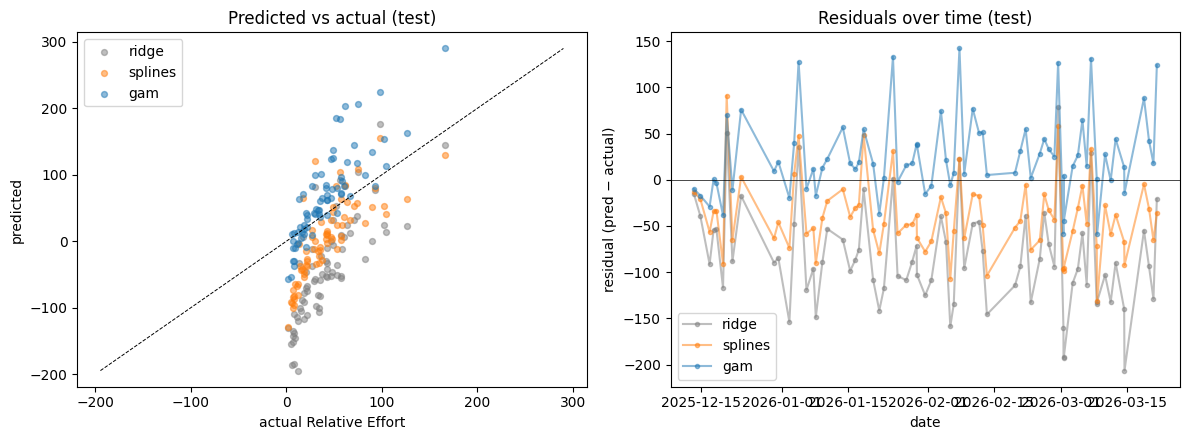

In [9]:
predictions = pd.DataFrame({
    "date": test_df["activity_dt"],
    "y_true": y_test.to_numpy(),
    "ridge": ridge.predict(X_test),
    "splines": spline_search.best_estimator_.predict(X_test),
    "gam": gam.predict(X_test_gam),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for name, color in [("ridge", "tab:gray"), ("splines", "tab:orange"), ("gam", "tab:blue")]:
    ax.scatter(predictions["y_true"], predictions[name], alpha=0.5, label=name, color=color, s=18)
lim = [min(predictions[["y_true", "ridge", "splines", "gam"]].min()), max(predictions[["y_true", "ridge", "splines", "gam"]].max())]
ax.plot(lim, lim, "k--", linewidth=0.7)
ax.set_xlabel("actual Relative Effort"); ax.set_ylabel("predicted")
ax.set_title("Predicted vs actual (test)"); ax.legend()

ax = axes[1]
for name, color in [("ridge", "tab:gray"), ("splines", "tab:orange"), ("gam", "tab:blue")]:
    ax.plot(predictions["date"], predictions[name] - predictions["y_true"], "o-", alpha=0.5, label=name, color=color, markersize=3)
ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("date"); ax.set_ylabel("residual (pred − actual)")
ax.set_title("Residuals over time (test)"); ax.legend()
fig.tight_layout()

## 3.7 Limitations

**Distribution shift in the held-out tail.** The last 15% of activities are the marathon-block training (2026), dominated by deliberately easy taper runs. Concretely: train mean Relative Effort ≈ 86 vs test mean ≈ 41, with about 40% of test activities at higher 28-day mileage than anything in train. CV RMSE on the training era is therefore much smaller than the test RMSE — the model correctly learns "high training load → high effort" but the taper deliberately decouples that during race week. CV-fold metrics are a fairer headline number than the single tail-15% test for this dataset.

**Marathon-time extrapolation.** The chosen target is per-activity Relative Effort, not race finishing time. To translate to a marathon-time prediction one would invert the GAM: fix `distance_km = 42.195`, set a target HR-zone distribution (e.g. mostly Z3 with a Z4 tail), and solve for the `mean_pace` that yields a chosen Relative Effort budget. Then `predicted_finish = 42.195 / pace`. This is unreliable because Strava's Relative Effort saturates at long durations — extrapolation is beyond the support of the data. The proposal pivoted to per-activity effort precisely for this reason; a direct race-time model is left as future work.